In [23]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

''' data for this simulation was drawn from 
a model y_i = f(x_i) + ε_i, where xi ~ U([0, 1]), ε_i ~ N (0, 1/4), 
and f(x) is the step function'''

# Define the step function
def step_function(x):
    return np.where(x < 0.35, 0, np.where(x < 0.45, 0.7, np.where(x < 0.55, 1.4, np.where(x < 0.65, 0.7, 0))))

# Vectorize the function so it can operate on numpy arrays
vectorized_step_function = np.vectorize(step_function, otypes=[np.float64])

# Simulation parameters
n_data_points = 500
n_simulations = 100
n_bootstrap = 1000
np.random.seed(42)

# Perform simulations
mse_results = []
for _ in range(n_simulations):
    x = np.random.uniform(0, 1, n_data_points).reshape(-1, 1)  # shape (n_data_points, 1)
    y_true = step_function(x.flatten())
    noise = np.random.normal(0, np.sqrt(0.25), n_data_points)
    y = y_true + noise
    
    # Bagging
    tree_model = DecisionTreeRegressor(max_leaf_nodes=5)
    predictions = np.zeros(n_data_points)
    for _ in range(n_bootstrap):
        indices = np.random.choice(n_data_points, n_data_points, replace=True)
        tree_model.fit(x[indices], y[indices])
        predictions += tree_model.predict(x)
        
    # prediction of bagged trees
    predictions /= n_bootstrap
    mse_results.append(mean_squared_error(y, predictions))

# Calculate average MSE
average_mse = np.mean(mse_results)
print("Average MSE:", average_mse)


Average MSE: 0.24321829110235002


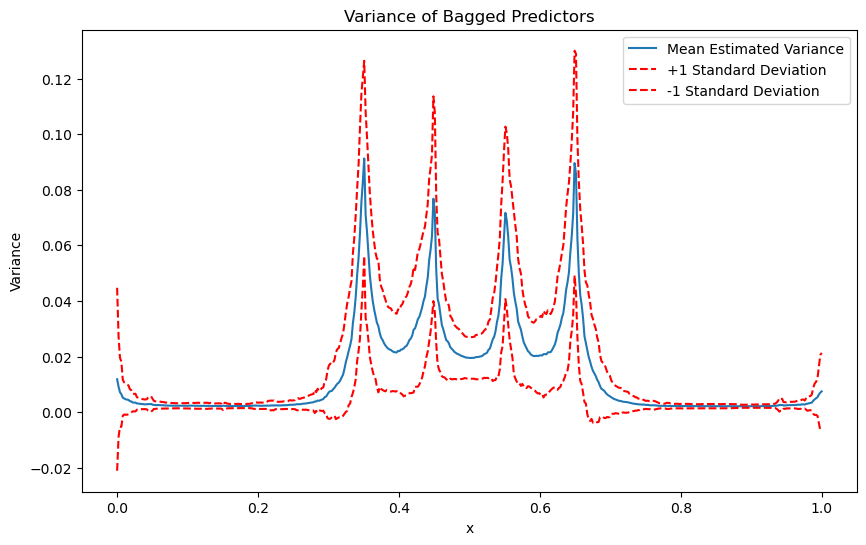

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# Define the step function
def step_function(x):
    return np.where(x < 0.35, 0, np.where(x < 0.45, 0.7, np.where(x < 0.55, 1.4, np.where(x < 0.65, 0.7, 0))))

# Simulation parameters
n_data_points = 500
n_simulations = 100
n_bootstrap = 1000

# Generate data
np.random.seed(42)
x_values = np.linspace(0, 1, n_data_points)
''' np.linspace generates evenly spaced values over a specified interval. 
In the context of plotting the variance or other statistical measures as a function of x, 
it ensures that you have a consistent set of x points where the variance is evaluated. 
this gives a smooth and continuous visualization, allowing us to see trends and patterns 
more clearly across the entire range of x'''

variances = np.zeros((n_simulations, n_data_points))

# Simulation
for i in range(n_simulations):
    y_true = step_function(x_values)
    noise = np.random.normal(0, np.sqrt(0.25), n_data_points)
    y = y_true + noise
    tree_model = DecisionTreeRegressor(max_leaf_nodes=5)
    predictions = np.zeros((n_bootstrap, n_data_points))
    
    for b in range(n_bootstrap):
        indices = np.random.choice(n_data_points, n_data_points, replace=True)
        tree_model.fit(x_values[indices].reshape(-1, 1), y[indices])
        predictions[b, :] = tree_model.predict(x_values.reshape(-1, 1))
    
    variances[i, :] = predictions.var(axis=0)

# Plotting
mean_variances = variances.mean(axis=0)
std_deviation = variances.std(axis=0)

plt.figure(figsize=(10, 6))
plt.plot(x_values, mean_variances, label='Mean Estimated Variance')
plt.plot(x_values, mean_variances + std_deviation, 'r--', label='+1 Standard Deviation')
plt.plot(x_values, mean_variances - std_deviation, 'r--', label='-1 Standard Deviation')
plt.title('Variance of Bagged Predictors')
plt.xlabel('x')
plt.ylabel('Variance')
plt.legend()
plt.show()


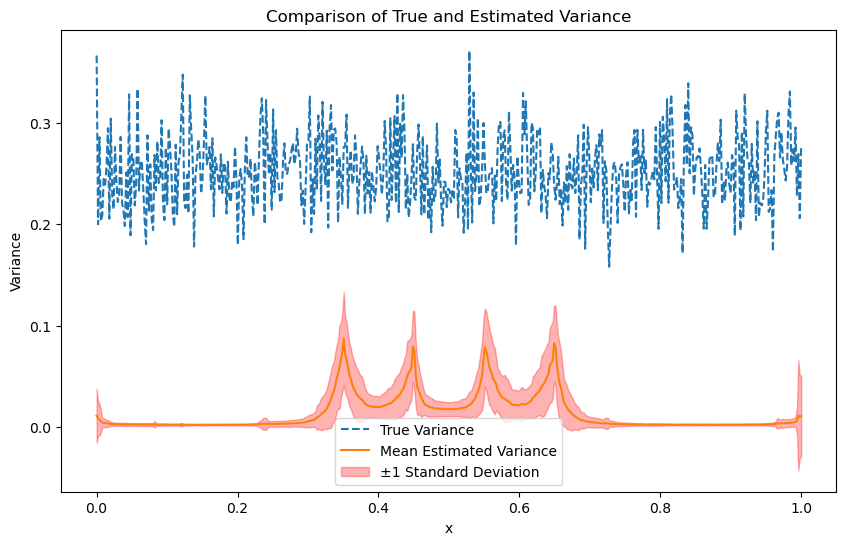

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# Step function as the true function
def step_function(x):
    return np.where(x < 0.35, 0, np.where(x < 0.45, 0.7, np.where(x < 0.55, 1.4, np.where(x < 0.65, 0.7, 0))))

# Sim Parameters
n_data_points = 500
n_simulations = 1000
n_bootstrap = 10000
x_values = np.linspace(0, 1, n_data_points)

# Arrays to store variances
true_variances = np.zeros(n_data_points)
estimated_variances = np.zeros((n_simulations, n_data_points))

# Perform simulations
for i in range(n_simulations):
    y_true = step_function(x_values)
    noise = np.random.normal(0, np.sqrt(0.25), n_data_points)
    y_noisy = y_true + noise
    
    # Calculate true variance without bagging
    if i == 0:
        true_variances = (y_noisy - y_true) ** 2
    else:
        true_variances += (y_noisy - y_true) ** 2
    
    # Bagging and prediction variance estimation
    tree_model = DecisionTreeRegressor(max_leaf_nodes=5)
    predictions = np.zeros((n_bootstrap, n_data_points))
    
    for b in range(n_bootstrap):
        indices = np.random.choice(n_data_points, n_data_points, replace=True)
        tree_model.fit(x_values[indices].reshape(-1, 1), y_noisy[indices])
        predictions[b, :] = tree_model.predict(x_values.reshape(-1, 1))
    
    estimated_variances[i, :] = predictions.var(axis=0)

# Average the variances
true_variances /= n_simulations
mean_estimated_variances = estimated_variances.mean(axis=0)
std_deviation = estimated_variances.std(axis=0)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(x_values, true_variances, label='True Variance', linestyle='--')
plt.plot(x_values, mean_estimated_variances, label='Mean Estimated Variance')
plt.fill_between(x_values, mean_estimated_variances - std_deviation, mean_estimated_variances + std_deviation, color='red', alpha=0.3, label='±1 Standard Deviation')
plt.title('Comparison of True and Estimated Variance')
plt.xlabel('x')
plt.ylabel('Variance')
plt.legend()
plt.show()


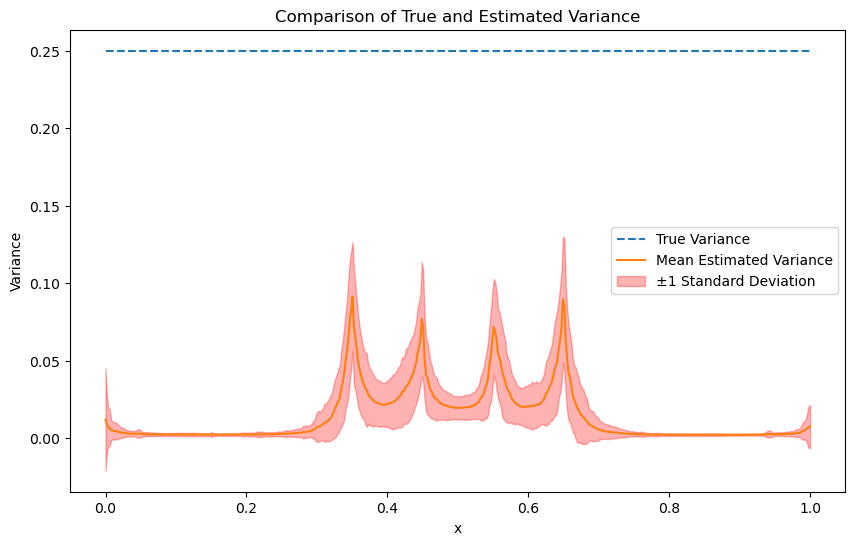

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# Define the step function as the true function
def step_function(x):
    return np.where(x < 0.35, 0, np.where(x < 0.45, 0.7, np.where(x < 0.55, 1.4, np.where(x < 0.65, 0.7, 0))))

# Simulation parameters
n_data_points = 500
n_simulations = 100
n_bootstrap = 1000
x_values = np.linspace(0, 1, n_data_points)
np.random.seed(42)

# True variance is constant since noise variance is constant
true_variance = 0.25

# Array to store variances from bootstrap samples
estimated_variances = np.zeros((n_simulations, n_data_points))

# Simulation
for i in range(n_simulations):
    y_true = step_function(x_values)
    noise = np.random.normal(0, np.sqrt(0.25), n_data_points)
    y_noisy = y_true + noise

    # Bagging and variance estimation
    tree_model = DecisionTreeRegressor(max_leaf_nodes=5)
    predictions = np.zeros((n_bootstrap, n_data_points))
    
    for b in range(n_bootstrap):
        indices = np.random.choice(n_data_points, n_data_points, replace=True)
        tree_model.fit(x_values[indices].reshape(-1, 1), y_noisy[indices])
        predictions[b, :] = tree_model.predict(x_values.reshape(-1, 1))
    
    estimated_variances[i, :] = predictions.var(axis=0)

# Average estimated variances
mean_estimated_variances = estimated_variances.mean(axis=0)
std_deviation = estimated_variances.std(axis=0)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(x_values, np.full_like(x_values, true_variance), label='True Variance', linestyle='--')
plt.plot(x_values, mean_estimated_variances, label='Mean Estimated Variance')
plt.fill_between(x_values, mean_estimated_variances - std_deviation, mean_estimated_variances + std_deviation, color='red', alpha=0.3, label='±1 Standard Deviation')
plt.title('Comparison of True and Estimated Variance')
plt.xlabel('x')
plt.ylabel('Variance')
plt.legend()
plt.show()


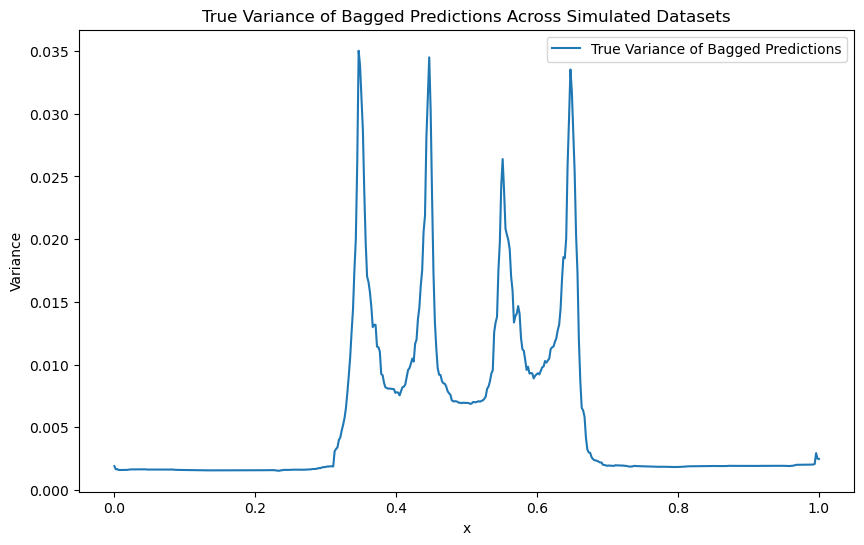

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# Define the step function as the true function
def step_function(x):
    return np.where(x < 0.35, 0, np.where(x < 0.45, 0.7, np.where(x < 0.55, 1.4, np.where(x < 0.65, 0.7, 0))))

# Simulation parameters
n_data_points = 500
n_simulations = 100  # Number of different datasets to simulate
n_bootstrap = 1000  # Number of bootstrap samples for bagging
x_values = np.linspace(0, 1, n_data_points)

# Array to store the predictions from each simulation
all_predictions = np.zeros((n_simulations, n_data_points))

# Generate multiple simulated datasets and perform predictions
for i in range(n_simulations):
    y_true = step_function(x_values)
    noise = np.random.normal(0, np.sqrt(0.25), n_data_points)
    y_noisy = y_true + noise

    # Bagging and prediction
    tree_model = DecisionTreeRegressor(max_leaf_nodes=5)
    predictions = np.zeros((n_bootstrap, n_data_points))
    
    for b in range(n_bootstrap):
        indices = np.random.choice(n_data_points, n_data_points, replace=True)
        tree_model.fit(x_values[indices].reshape(-1, 1), y_noisy[indices])
        predictions[b, :] = tree_model.predict(x_values.reshape(-1, 1))
    
    # Average predictions across bootstrap samples
    all_predictions[i, :] = predictions.mean(axis=0)

# Calculate true variance of bagged predictions
true_variances = all_predictions.var(axis=0)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(x_values, true_variances, label='True Variance of Bagged Predictions')
plt.title('True Variance of Bagged Predictions Across Simulated Datasets')
plt.xlabel('x')
plt.ylabel('Variance')
plt.legend()
plt.show()
